In [ ]:
import srsly 
data = srsly.read_jsonl("/home/apjanco/projects/misnomer/tests/test_data.jsonl")
data = list(data)

In [ ]:
import misnomer

for d in data:
    report = misnomer.score(
                predicted=d['predicted_text'],
                ground_truth=d['ground_truth'],
                )
    d['document_score'] = report.document_score
    d['semantic_error_count'] = report.semantic_error_count
    d['obvious_error_count'] = report.obvious_error_count

In [4]:
import srsly 
data = srsly.read_jsonl("/home/apjanco/projects/misnomer/tests/test_data_semerr.jsonl")
data = list(data)

In [3]:
data[5]

{'image_path': 5,
 'ground_truth': 'is to be made at a meeting of Labour',
 'predicted_text': 'is to be made at a meeting of Labour',
 'cer': 0.0,
 'wer': 0.0,
 'semantic_error': 0.0,
 'kl_divergence': 0.0,
 'entropy': 2.9802000000000003e-06,
 'mean_gt_rank': 3176.4444444444,
 'top5_accuracy': 0.1111111111,
 'inference_time': 10.3478019238,
 'error': None,
 'document_score': 0.0,
 'semantic_error_count': 0,
 'obvious_error_count': 0}

In [8]:
flagged = [r for r in data if r["document_score"] != 0 or r["semantic_error_count"] != 0]
print(f"{len(flagged)} of {len(data)} documents have semantic errors or document score issues.")

69 of 99 documents have semantic errors or document score issues.


In [9]:
import pandas as pd 
df = pd.DataFrame(flagged)
df

,image_path,ground_truth,predicted_text,cer,wer,semantic_error,kl_divergence,entropy,mean_gt_rank,top5_accuracy,inference_time,error,document_score,semantic_error_count,obvious_error_count
0,3,M Ps tomorrow. Mr. Michael Foot has,MPs tomorrow. Mr. Michael Foot has,2.857143,28.571430,2.463759,23.0,0.685547,6327.666667,0.000000,14.373969,None,0.617337,1,0
1,4,"Griffiths, M P for Manchester Exchange .","Griffiths, HP for Manchester Exchange.",7.500000,57.142860,0.000000,23.0,0.000323,4282.800000,0.100000,12.759424,None,0.508395,2,0
2,6,A MOVE to stop Mr. Gaitskell from,A move to stop Mr. Gaitskell from,12.121212,14.285715,0.000000,23.0,0.392090,5758.454545,0.090909,10.288932,None,1.000000,1,0
3,7,0M P for Manchester Exchange .,014 P for Manchester Exchange.,10.000000,50.000000,0.000000,23.0,0.000000,5647.285714,0.142857,4.157860,None,0.561809,2,0
4,8,A MOVE to stop Mr. Gaitskell from nominating,A MOVE to stop Mr. Cathell from nominating,9.090909,12.500000,0.000000,23.0,0.000000,5758.363636,0.090909,6.151536,None,0.561556,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,90,"National Independence Party ( 280,000 members )",National Independence Party (280'000 member),8.510638,57.142860,0.000000,23.0,0.447021,4301.307692,0.076923,9.074705,None,0.316161,1,1
65,91,"Congress ( 400,000 ) will meet in London today","Congress (400,000) will meet in London today t...",86.956519,111.111116,0.000000,23.0,0.003498,1027.750000,0.062500,8.690211,None,0.331442,1,0
66,92,to discuss a common course of action .,to discuss a common course of action.,2.631579,25.000000,0.000000,23.0,0.002417,1864.375000,0.125000,9.693828,None,0.522719,1,0
67,93,"Macleod , is insisting on a policy of change .","Macleod, is insisting on a policy of change.",6.521739,40.000001,1.916667,23.0,0.000007,6519.583333,0.000000,5.898205,None,0.446579,2,0


<Axes: xlabel='semantic_error_count'>

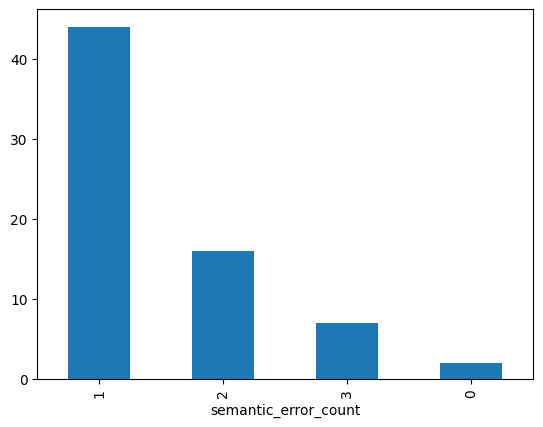

In [ ]:
# plot of semantic error count 
df["semantic_error_count"].value_counts().plot(kind="bar")   


<Axes: xlabel='document_score'>

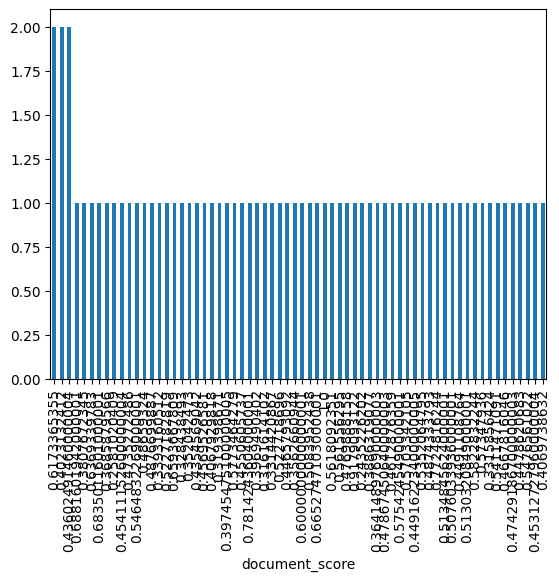

In [13]:
df["document_score"].value_counts().plot(kind="bar")   


In [15]:
df[df['semantic_error_count'] > 2].sort_values(by="document_score")

,image_path,ground_truth,predicted_text,cer,wer,semantic_error,kl_divergence,entropy,mean_gt_rank,top5_accuracy,inference_time,error,document_score,semantic_error_count,obvious_error_count
26,37,"appear to "" prop up "" an out-dated institution .","appeal to ""prop up"" an out-dated institution.",8.333334,69.999999,0.749990,21.833333,0.001262,1901.833333,0.083333,7.473769,None,0.331586,3,1
68,97,"chief aide , Mr. Julius Greenfield , telephoned","chief vide, mr. julius greenfield, telephoned",12.765957,75.000000,0.000000,23.000000,0.000001,12946.916667,0.083333,8.900257,None,0.406974,3,1
55,77,"Mr. Iain Macleod , is insisting on a policy of...","Mr. lain Hacleod, is insisting on a policy of ...",7.272727,41.666666,0.000000,23.000000,0.066895,5209.600000,0.066667,9.892099,None,0.435457,3,0
5,9,meeting of Labour 0M Ps tommorow . Mr. Michael,meeting of Labour 017 Mr Komarov. Mr. Michael,19.565217,44.444445,0.000000,23.000000,0.000000,2908.785714,0.071429,6.866878,None,0.476989,3,0
48,66,"challenge from Sir Roy Welensky , the Federal ...","Challenge from Sir Roy Welensky, the Federal P...",5.454545,50.000000,0.708316,18.166667,0.001943,7985.166667,0.083333,7.125464,None,0.486593,3,0
19,26,"which would appear to "" prop up "" an out-","which would appear to ""prop up"" an out.",7.317073,50.000000,0.000000,23.000000,0.001728,990.545455,0.090909,10.557238,None,0.513485,3,0
34,48,Peeresses have been created . Most Labour,Peresses have been created. Most Calour,9.756097,57.142860,2.875000,23.000000,0.000000,15936.750000,0.000000,10.084203,None,0.665275,3,0


In [ ]:
# clean dataframe of all records with the ground truth and predicted text side by side

new_df = pd.DataFrame(data)

# show only ground truth and predicted text 
new_df[["ground_truth", "predicted_text"]]

,ground_truth,predicted_text
0,put down a resolution on the subject,put down a resolution on the subject
1,and he is to be backed by Mr. Will,and he is to be backed by Mr. Will
2,nominating any more Labour life Peers,nominating any more Labour life Peers
3,M Ps tomorrow. Mr. Michael Foot has,MPs tomorrow. Mr. Michael Foot has
4,"Griffiths, M P for Manchester Exchange .","Griffiths, HP for Manchester Exchange."
...,...,...
94,and Mr. Harry Nkumbula's African National,and Mr. Harry Nkumbula's African National
95,Delegates from Mr. Kenneth Kaunda's United,Delegates from Mr. Kenneth Kaunda's United
96,Sir Roy is violently opposed to Africans,Sir Roy is violently opposed to Africans getti...
97,"chief aide , Mr. Julius Greenfield , telephoned","chief vide, mr. julius greenfield, telephoned"


In [ ]:
# clean dataframe of all records with the ground truth and predicted labels side by side
